# Mantenimiento predictivo

##### DEFINICION DEL PROBLEMA

Desarrollar un modelo de clasificacion binaria capaz de detectar condiciones de falla en maquinaria industrial a partir de datos de sensores, priorizando la reduccion de fallas no detectadas (falsos negativos) para minimizar downtime y costos de mantenimiento correctivo

##### TIPO DE PROBLEMA

Clasificación supervisada binaria

Una falla es cualquier condicion que implique que la maquina requiere intervencion inmediata o puede detener producción

##### Costos Implicitos

- Falso Negativo (No detecta fallas)
    - La maquina falla en producción
    - Paro de linea
    - Costos altos


- Falso positivo (alerta falsa)
    - Mantenimiento innecesario
    - Costo bajo-moderado

! Falsos negativos son más costosos que falsos positivos

##### METRICAS
- Recall -> Cuantas fallas reales detecto? (Prioritaria por negocio)

- Precision -> Cuantas alertas realmente son fallas?
- F1-score -> Balance

- ROC-AUC (secundaria) -> Para comparar modelos

## Imports

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score

In [9]:
df = pd.read_csv('ai4i2020.csv')
df.set_index('UDI', inplace = True)
#df.drop(columns = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace = True)

In [10]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,,
1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [11]:
df.shape

(10000, 13)

El dataset tiene 10,000 filas y 13 columnas.

En el sitio web de donde se recopilaron los datos marca que las columnas de:
- Machine failure
- TWF
- HDF
- PWF
- OSF 
- RNF

Son targets, pero para este proyecto me centrare en la columna de Machine failure como target, seguramente las demas columnas podran ocacionar data leakage por lo que se tendran que eliminar

#### Analisis del target

In [15]:
df['Machine failure'].value_counts()

0    9661
1     339
Name: Machine failure, dtype: int64

El dataset esta desbalanceado, contiene 9661 0 y 339 1

In [17]:
df['Machine failure'].value_counts(normalize = True)

0    0.9661
1    0.0339
Name: Machine failure, dtype: float64

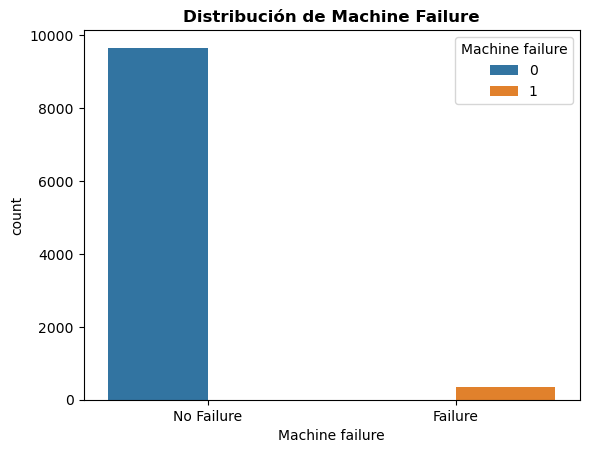

In [18]:
sns.countplot(data=df, x='Machine failure', hue='Machine failure')
plt.title('Distribución de Machine Failure', fontweight='bold')
plt.xticks([0,1], ['No Failure', 'Failure']);

El 96.6% de los datos en el target no son fallas. 

El 3.3% de los datos en el target son fallas.

Por lo que podemos entender que el dataset tiene un desbalance demasiado grande, lo cual podria dificultar el correcto desempeño del modelo.

El desbalance hace que metricas como accuracy sean poco confiables y obliga a priorizar metricas como recall y estrategias especificas para manejar clases minoritarias

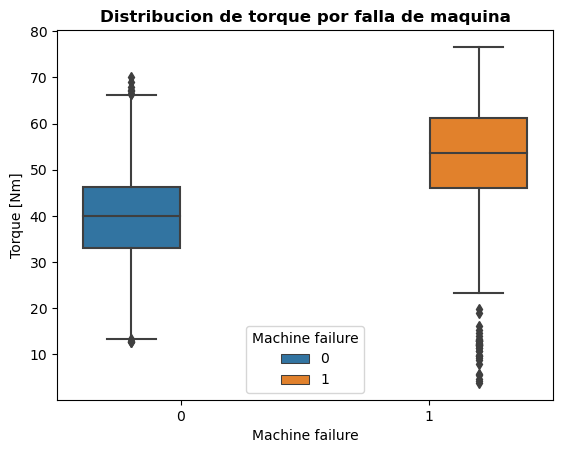

In [23]:
sns.boxplot(x = df['Machine failure'], y = df['Torque [Nm]'], hue = df['Machine failure'])
plt.title('Distribucion de torque por falla de maquina', fontweight='bold');

Torque muestra una distribucion desplazada hacia valores mas altos en observaciones con falla, lo que sugiere asociacion con condiciones de mayor carga mecanica.
Sin embargo, el solapamiento entre classes indica que su capacidad discriminativa individual es limitada, por lo que debera evaluarse en conbinacion con otras variables.

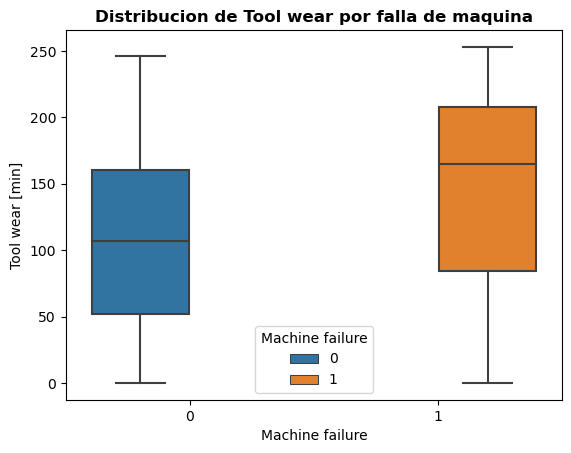

In [25]:
sns.boxplot(x = df['Machine failure'], y = df['Tool wear [min]'], hue = df['Machine failure']);
plt.title('Distribucion de Tool wear por falla de maquina', fontweight='bold');

Tool wear muestra una tendencia hacia valores mas altos en observaciones con falla, lo cual es consistence con el desgaste progresivo de componentes mecanicos.
Aunque existe solapamiento entre clases, la variable podria aportar valor predictivo en combinacion con otras caracteristicas operativas.

No presenta indicios evidentes de leakage, ya que representa informacion potencialmente disponible antes del evento de falla

#### Mapa de correlacion de features

In [28]:
df_corr = df.drop(columns = ['Product ID', 'Type'])
corr_matrix = df_corr.corr()

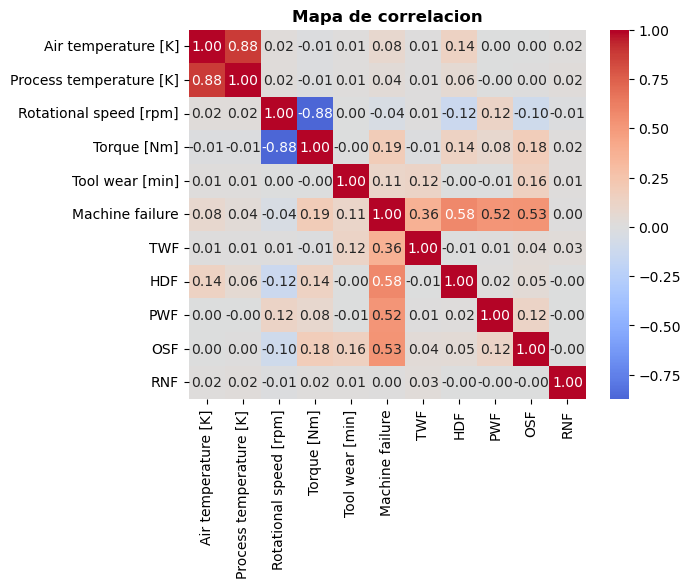

In [29]:
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Mapa de correlacion', fontweight='bold');

Las variables HDF, PWF, OSF presentan correlacion moderada con Machine failure, sin embargo, no deben considerarse predictores validos, ya que forman parte de la deficion logica del target principal,
lo que introduciria leakage

In [31]:
df.drop(columns = ['Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace = True)

Decidí conservar Type porque representa información operacional disponible antes del evento de falla y podría capturar diferencias estructurales entre configuraciones de máquina.
Su utilidad predictiva será validada empíricamente durante el modelado.

#### Split de target y features

In [34]:
X = df.drop(columns = 'Machine failure')
X = pd.get_dummies(X, columns = ['Type'], drop_first = True)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

Dado el fuerte desbalance del dataset, la estratificación es necesaria para preservar una proporción representativa de fallas y no fallas tanto en entrenamiento como en prueba. 
Esto evita evaluaciones sesgadas o inestables y garantiza que el modelo sea entrenado y evaluado bajo distribuciones consistentes con el problema real.

Utilizare one-hot encoding porque Type es una variable categórica nominal sin una relación ordinal garantizada entre categorías. 
Esta estrategia permite que Logistic Regression evalúe independientemente el efecto de cada tipo de máquina sin imponer una jerarquía artificial.

#### Escalado de features para Logistic Regression

In [38]:
scaler = StandardScaler()

#Fit solo con Train
X_train_scaled = scaler.fit_transform(X_train)

#Transform usando scaler de train
X_test_scaled = scaler.transform(X_test)

El escalado debe realizarse después del train-test split para evitar data leakage. 
El scaler debe ajustarse únicamente con los datos de entrenamiento y posteriormente aplicarse tanto a train como a test, garantizando que el modelo no tenga acceso indirecto 
a información del conjunto de prueba durante el entrenamiento.

## Logistic Regression

In [41]:
#Modelo baseline
log_reg = LogisticRegression(
    class_weight = 'balanced',
    random_state = 42,
    max_iter = 1000
)

Iniciare utilizando class_weight='balanced' para compensar el desbalance sin alterar artificialmente la distribución de los datos. 
Esto permite establecer un baseline robusto y evaluar si el modelo mejora su capacidad de detección de fallas antes de considerar técnicas más agresivas como oversampling.

#### Logistic Regression cross validation

In [44]:
#Cross Validation
from sklearn.model_selection import cross_validate
cv_results = cross_validate(
    log_reg,
    X_train_scaled,
    y_train,
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

Seleccioné recall como métrica principal porque el costo de no detectar una falla supera significativamente el costo de una falsa alarma. 
Complementé esta evaluación con precision y F1-score para asegurar que la mejora en sensibilidad no comprometiera excesivamente la eficiencia operativa.

#### Resultados de Logistic Regression

In [47]:
LR_results = pd.DataFrame({
    'Modelo' : ['Logistic Regression'],
    'Recall': [cv_results['test_recall'].mean()],
    'Precision' : [cv_results['test_precision'].mean()],
    'F1' : [cv_results['test_f1'].mean()]
})
results = LR_results

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907


El comportamiento observado sugiere relaciones no lineales entre sensores y falla, lo que podria limitar la capacidad de Logistic Regression para construir una frontera
discriminativa suficientemente precisa

Mi hipotesis es que el bajo precision se debe a una cobinacion de tres factores:
- La posible presencia de relaciones no lineales entre sensores y fallas
- El solapamiento observado entre clases en el EDA
- El uso de class_weight = 'balanced', que incrementa la sensibilidad hacia la clase minoritaria prorizando recall a costa de mas falsos positivos

## Decision Tree Classifier

Probare primero Decision Tree porque los resultados del baseline sugieren que el problema podria presentar relaciones no lineales que Logistic Regression no captura adecuadamente.
Decision Tree permite modelar este tipo de patrones con menor complejidad que Random Forest y me permitira evaluar si una estructura no lineal mejora precision sin sacrificar recall
aunque vigilando cuidadosamente el riesgo de overfitting

El hiperparámetro principal que controlare sería max_depth, ya que limita directamente la complejidad del árbol y ayuda a prevenir que memorice patrones específicos del entrenamiento. 
Complementariamente revisaría min_samples_leaf y max_leaf_nodes para evitar particiones excesivamente específicas.

Entrenare primero un baseline para aislar el impacto del cambio de arquitectura. 
Si el árbol muestra mejoras claras, particularmente en precision manteniendo recall competitivo, entonces justificaría proceder con tuning mediante GridSearchCV.

No escalare las variables porque Decision Tree realiza particiones basadas en umbrales relativos dentro de cada feature, 
por lo que la magnitud absoluta de las variables no afecta su capacidad de aprendizaje.

In [55]:
#Decision Tree baseline 
tree = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42
)

In [56]:
#Cross validation
cv_results_tree = cross_validate(
    tree, 
    X_train,
    y_train, 
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

#### Resultados de Decision Tree 

In [58]:
DT_results = pd.DataFrame({
    'Modelo' : ['Decision Tree'],
    'Recall': [cv_results_tree['test_recall'].mean()],
    'Precision' : [cv_results_tree['test_precision'].mean()],
    'F1' : [cv_results_tree['test_f1'].mean()]
})
results = pd.concat([results, DT_results])

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968


La mejora considerable en precision sugiere que existen patrones no lineales o reglas tipo umbral que Logistic Regression no estaba capturando adecuadamante.
Decision Tree parece separar mejor las clases al modelar relaciones mas complejas entre sensores

Esperaria que Random Forest generalice mejor porque combina multiples arboles entrenados sobre distintos subconjuntos de datos y variables, reduciendo la varianza y mitigando 
el overfitting tipico de un Decision Tree. 
Esto permite obtener predicciones mas estables y robustas

## Random Forest Classifier

In [62]:
#Random Forest baseline
rf = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 42,
    n_estimators = 100
)

In [63]:
cv_results_rf = cross_validate(
    rf,
    X_train,
    y_train, 
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

#### Resultados Random Forest

In [65]:
RF_results = pd.DataFrame({
    'Modelo' : ['Random Forest'],
    'Recall': [cv_results_rf['test_recall'].mean()],
    'Precision' : [cv_results_rf['test_precision'].mean()],
    'F1' : [cv_results_rf['test_f1'].mean()]
})
results = pd.concat([results, RF_results])

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514


## XGBoost

El principal riesgo de XGBoost es el overfitting, ya que al construir arboles secuenciamente corrigiendo errores previos puede terminar aprendiendo ruido o patrones especificos
del entrenamiento si no se controlan adecuadamente hiperparametros como profundidad, learning rate o numero de estimadores

In [68]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<', '', regex=False)

X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)

In [69]:
#Peso de la clase minoritaria
scale_pos_weight = (
    y_train.value_counts()[0] / y_train.value_counts()[1]
)

In [70]:
#XGBoos modelo baseline
xgb_model = XGBClassifier(
    random_state = 42,
    n_estimators = 100,
    max_depth = 3,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'logloss'
)

In [71]:
#Cross validation
cv_results_xgb = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

#### Resultados XGBoost baseline

In [73]:
XGB_results = pd.DataFrame({
    'Modelo' : ['XGBoos baseline'],
    'Recall': [cv_results_xgb['test_recall'].mean()],
    'Precision' : [cv_results_xgb['test_precision'].mean()],
    'F1' : [cv_results_xgb['test_f1'].mean()]
})
results = pd.concat([results, XGB_results])

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819


XGboost parece mas alineado con la prioridad de minimizar fallas no detectadas, aunque introduce un costo operaciones considerable por el aumento de falsos positivos

Al ser el modelo con mayor recall sin una caida tan grave de precision, se realizara el tunning sobre XGBoost para optimizar el modelo tanto para recall como para F1 y observar su comportamiento, para finalmente evaluar el trade-off de ambas opciones y tomar la mejor decision conforme al objetivo del proyecto.

#### GridSearchCV optimizado para recall

In [77]:
xgb_model = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight
)

In [78]:
#Grid de hiperparametros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

In [79]:
#GridSearchCV priorizando recall
grid_recall = GridSearchCV(
    estimator = xgb_model,
    param_grid = param_grid,
    scoring = 'recall',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

Aunque el tunning fue optimizado para recall, se monitorearon metricas complementarias para evaluar el impacto operacional del incremento de sensibilidad

In [81]:
#Entrenamiento
grid_recall.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='recall', verbose=1)

In [82]:
#Mejores resultados
print('Mejores parametros:')
print(grid_recall.best_params_)
print('\nMejor Recall:')
print(grid_recall.best_score_)

Mejores parametros:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

Mejor Recall:
0.9519191919191918


#### Resultados XGBoost optimizado para recall

In [84]:
best_xgb_recall = grid_recall.best_estimator_

cv_results_best_recall = cross_validate(
    best_xgb_recall,
    X_train,
    y_train,
    cv=5,
    scoring=['recall', 'precision', 'f1'],
    return_train_score=False
)

In [85]:
XGBR_results = pd.DataFrame({
    'Modelo' : ['XGBoost Recall'],
    'Recall': [cv_results_best_recall['test_recall'].mean()],
    'Precision' : [cv_results_best_recall['test_precision'].mean()],
    'F1' : [cv_results_best_recall['test_f1'].mean()]
})
results = pd.concat([results, XGBR_results])

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242


#### GridSearchCV optimizado para F1 score

In [87]:
#Modelo base para F1
xgb_model_f1 = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight
)

In [88]:
#Grid de hiperparametros
param_grid_f1 = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

In [89]:
#GridSearchCV optimizado para F1
grid_f1 = GridSearchCV(
    estimator=xgb_model_f1,
    param_grid=param_grid_f1,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [90]:
#Entrenamiento
grid_f1.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [91]:
#Mejores parametros
print('Mejores parametros')
print(grid_f1.best_params_)
print('\nMejor F1')
print(grid_f1.best_score_)

Mejores parametros
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

Mejor F1
0.7332101343742919


#### Resultados XGBoost optimizado para F1 score

In [93]:
best_xgb_f1 = grid_f1.best_estimator_

cv_results_best_f1 = cross_validate(
    best_xgb_f1,
    X_train,
    y_train,
    cv=5,
    scoring=['recall', 'precision', 'f1'],
    return_train_score=False
)

In [94]:
XGBF1_results = pd.DataFrame({
    'Modelo' : ['XGBoost F1'],
    'Recall': [cv_results_best_f1['test_recall'].mean()],
    'Precision' : [cv_results_best_f1['test_precision'].mean()],
    'F1' : [cv_results_best_f1['test_f1'].mean()]
})
results = pd.concat([results, XGBF1_results])

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242
0,XGBoost F1,0.767677,0.706661,0.733210


#### Modelo optimizado para recall:
- Maximiza deteccion pero puede generar sobre costo operacional

#### Modelo optimizado para F1:
- Sacrifica algo de sensibilidad a cambio de estabilidad operacional

Despues de comparar multiples enfoques de clasificacion, se selecciono XGBoost optimizado para F1-score como modelo final debido a que se presento el mejor equilibrio entre
capacidad de deteccion de fallas y control de falsas alarmas

Aunque la version optimizada para recall alcanzo una sensibilidad mayor, generaba una cantidad considerable de falsos positivos, lo que podria traducirse en inspecciones innecesarias
y costos operacionales elevados. Por otro lado, modelos como Random Forest mostraron una precision muy alta, pero sacrificando demasiado recall, aumentando el riesgo de fallas 
no detectadas

El modelo optimizado para F1 logro mantener un recall competitivo mientras incrementaba significativamente precision, ofreciendo un comportamiento mas balanceado y viable para un entorno industrial real.
Ademas, los resultados obtenidos reforzaron la hipotesis de que el problema presenta relaciones no lineales entre sensores y fallas, las cuales fueron capturadas de manera mas efectiva
por modelos basados en arboles y boosting que por Logistic Regression

## Modelo seleccionado

#### Comparacion de resultados entre modelos 

In [99]:
results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242
0,XGBoost F1,0.767677,0.706661,0.733210


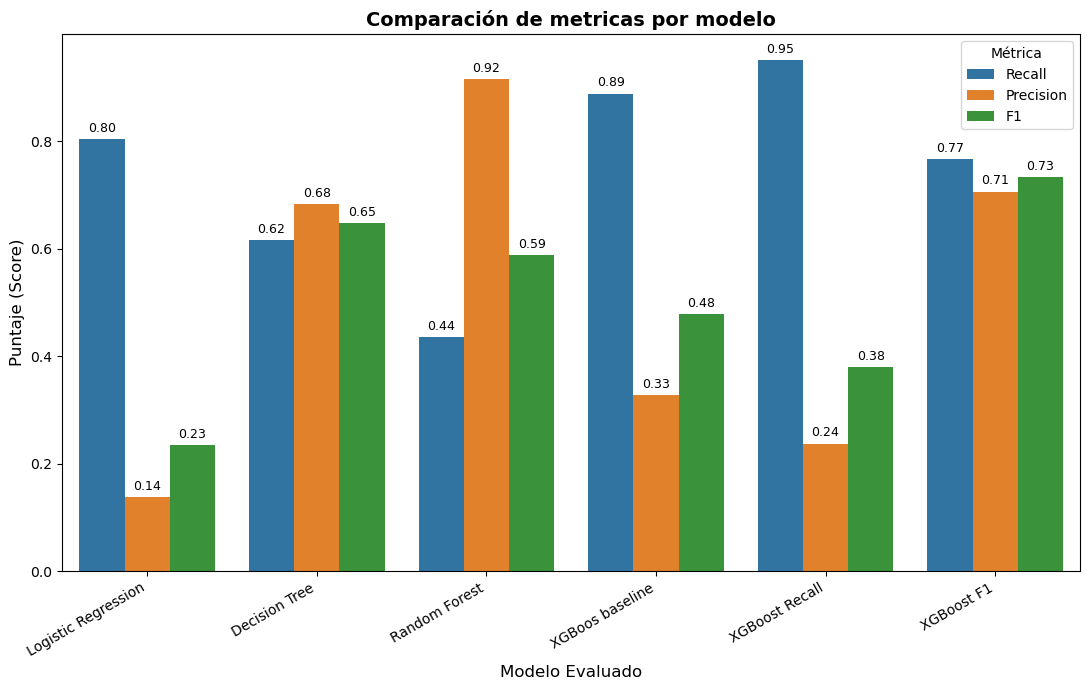

In [100]:
# 1. Transformar tu DataFrame 'results' a formato largo para Seaborn
results_long = pd.melt(
    results, id_vars = ['Modelo'], value_vars = ['Recall', 'Precision', 'F1']
)
results_long.columns = ['Modelo', 'Métrica', 'Valor']

plt.figure(figsize=(11, 7))

ax = sns.barplot(data=results_long, x = 'Modelo', y = 'Valor', hue = 'Métrica')

plt.title('Comparación de metricas por modelo', fontsize=14, fontweight='bold')
plt.xlabel('Modelo Evaluado', fontsize=12)
plt.ylabel('Puntaje (Score)', fontsize=12)
plt.xticks(rotation=30, ha='right') 

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

#### Resultados sobre test

In [102]:
#Modelo final seleccionado
final_model = grid_f1.best_estimator_

In [103]:
#Prediccion sobre TEST
y_pred = final_model.predict(X_test)

In [104]:
#Metricass finales
XGBtest_results = pd.DataFrame({
    'Modelo' : ['XGBoost Test'],
    'Recall': [recall_score(y_test, y_pred)],
    'Precision' : [precision_score(y_test, y_pred)],
    'F1' : [f1_score(y_test, y_pred)]
})
results = pd.concat([results, XGBtest_results])

results

,Modelo,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242
0,XGBoost F1,0.767677,0.706661,0.733210
0,XGBoost Test,0.750000,0.772727,0.761194


## Matriz de confusion

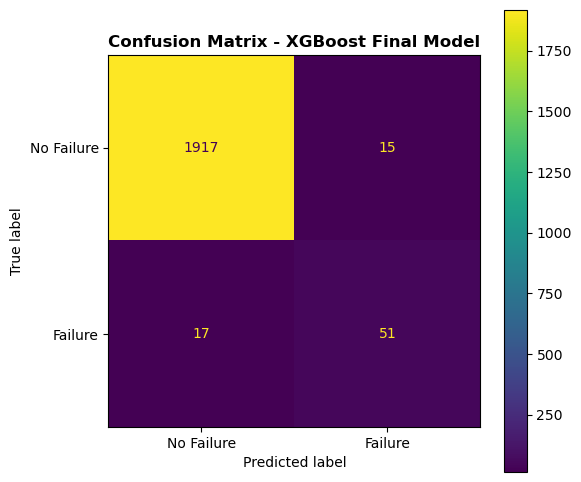

In [106]:
#Matriz de confusion
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - XGBoost Final Model", fontweight='bold')
plt.show()

In [107]:
#Reporte completo
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.77      0.75      0.76        68

    accuracy                           0.98      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.98      0.98      0.98      2000



En el conjunto de pruba, el modelo logro detectar correctamente 51 fallas reales mientras mantuvo una cantidad relativamente baja de falsas alarmas (15 falsos positivos).
Aunque todavia dejo pasar 17 fallas reales, el balance general entre recall y precision resulto operacionalmente razonable considerando el objetivo del proyecto

Ademas, las metricas obtenidas en test fueron consistentes con las observadas durante Cross Validation, lo que sugiere buena capacidad de generalizacion y ausencia clara de overfitting

Desde una perspectiva de negocio, los falsos negativos continuan siendo el principal riesgo debido al consto asociado a fallas no detectadas.
Sin embargo, el modelo logra reducir una proporcion importante de estas fallas potenciales, lo que podria representar ahorros significativos en mantenimiento correctivo y downtime industrial.

Por ello, el modelo podria implementarse como sistema de apoyo para mantenimiento predictivo, complementando inspecciones tecnicas y mejorando conforme se recopilen nuevos datos operacionales

## Feature importance

In [110]:
#Importacias
importance = final_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importance
})

In [111]:
#Ordenar
feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

In [112]:
#Mostrar tabla
print(feature_importance)

                 Feature  Importance
2   Rotational speed rpm    0.351488
3              Torque Nm    0.260947
4          Tool wear min    0.223141
0      Air temperature K    0.055115
1  Process temperature K    0.043855
5                 Type_L    0.042336
6                 Type_M    0.023117


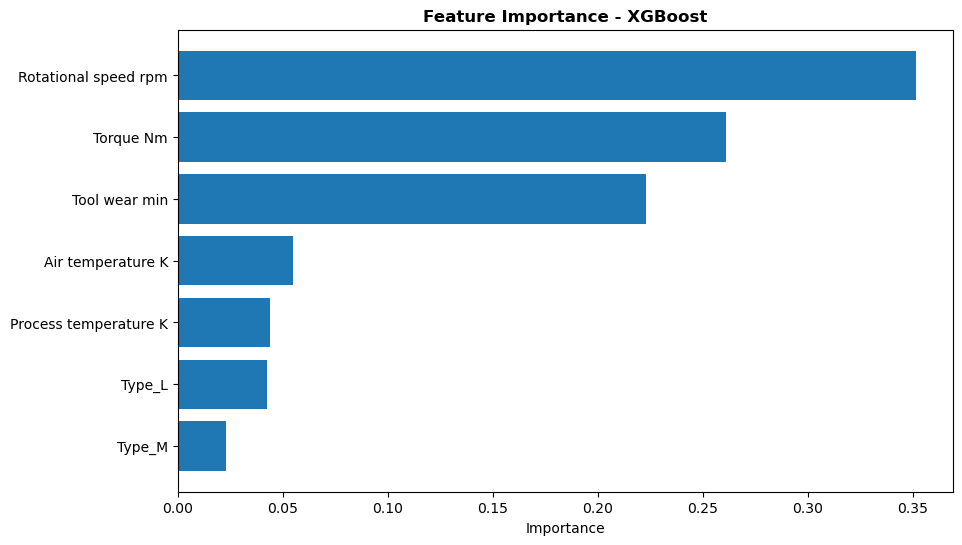

In [113]:
#Grafico
plt.figure(figsize = (10, 6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()
plt.title('Feature Importance - XGBoost', fontweight='bold')
plt.xlabel('Importance')
plt.show()

La velocidad rotacional fue la variable con mayor importancia dentro del modelo, lo que sugiere que cambios en el comportamiento dinamico de la maquina estan fuertemente relacionados
con la ocurrencia de fallas. Desde una perspectiva industrial, velocidades anormales podrian reflejar condiciones de operacion inestables
friccion excesiva o esfuercos mecanicos que aumentan el riesgo de daño en los componentes

El torque tambien mostro una influencia en las predicciones. Esto resulta coherente con el contexto industrial, ya que un incremento en torque puede indicar que la maquinaria esta realizando un
esfuerzo mecanico mayor al esperado, aumentando el desgaste y la probabilidad de falla

El desgaste de herramienta (tool wear) aparecio como otra variable relevante, lo cual tiene sentido operativo debido a que herramientas mas desgastadas tienden a perder eficiencia y
estabulidad mecanica, incrementando la probabilidad de anomalias o fallas durante la operacion

En conjunto, las variables mas importantes parecen estar relacionadas con condiciones de esfuerzo mecanico y degradacion operacional, lo que sugiere que el modelo aprendio patrones
coherentes con el comportamiento fisico esperado de maquinaria industrial

## Obtener falsos negativos

In [119]:
#Obtener falsos negativos
results_df = X_test.copy()

results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred

#Falsos negativos
false_negatives = results_df[
(results_df['Actual'] == 1) &
(results_df['Predicted'] ==0)
]

false_negatives.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_L,Type_M,Actual,Predicted
UDI,,,,,,,,,
4852,303.7,312.1,1363,51.8,90,1,0,1,0
7885,300.8,312.4,1465,59.1,91,1,0,1,0
9175,297.8,308.9,1871,25.6,200,1,0,1,0
2672,299.7,309.3,1399,41.9,221,0,1,1,0
2865,300.6,309.4,1380,47.6,246,0,0,1,0


In [120]:
print('Cantidad de falsos negativos:')
print(len(false_negatives))

Cantidad de falsos negativos:
17


Algunas fallas ocurren en condiciones donde la maquina gira rapidamente pero sin una carga mecanica suficientemente alta para diferenciarse claramente de una operacion normal

Las fallas no detectadas presentan sensores menos extremos y mas parecidos a operacion normal

La combinacion de torque bajo y velocidad rotacional relativamente alta resulta menos intuitiva desde una perspectiva operacional y podria indicar zonas ambiguas donde las fallas
presentan patrones similares a condiciones normales

Algunas fallas parecen depender de patrones mas complejos o temporales que no pueden distinguirse completamente usando unicamente mediciones instantaneas de sensores

## Falsos positivos

In [124]:
#Falsos positivos
false_positives = results_df[
(results_df['Actual'] == 0) &
(results_df['Predicted'] == 1)
]

#Mostrar resultados
false_positives.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_L,Type_M,Actual,Predicted
UDI,,,,,,,,,
4232,302.2,310.8,1340,47.8,54,1,0,0,1
8022,301.0,312.0,1499,34.6,207,0,1,0,1
1419,298.8,309.9,1320,47.4,210,1,0,0,1
5912,300.8,310.4,1288,64.0,3,0,1,0,1
5490,302.6,312.1,1499,35.0,215,1,0,0,1


In [125]:
print('Cantidad de falsos positivos:')
print(len(false_positives))

Cantidad de falsos positivos:
15


El analisis de errores mostro que tanto falsos positivos como falsos negativos comparten patrones similares en variables como torque, rotational speed y tool wear.
Esto siguiere la existencia de zonas ambiguas donde ciertas condiciones operacioneales presentan comportamientos muy parecidos entre estados de falla y no falla,
dificultando una separacion completamente clara incluso para modelos avanzados como XGBoost

## CONCLUSION GENERAL DEL PROYECTO

El objetivo del proyecto fue desarrollar un modelo de clasificacion capaz de detectar fallas en maquinaria industrial utilizando variables de telemetria provenientes del dataset
AI4I 2020 Predicitve Maintenance
Mas alla de maximizar metricas, el enfoque principal consistio en contruir un modelo alineado con necesidades operacionales reales, prorizando la deteccion temprana de fallas 
para reducir costos asociados a mantenimiento correctivo y downtime industrial

## HALLAZGOS DEL EDA

Durante el analisis exploratorio se identifico un desbalance importante entre clases, con una proporcion considerablemente mayor de registros de no falla respecto a fallas reales.
Ademas, variables como torque y rotational speed mostraron solapamiento entre clases, sugiriendo desde etapas tempranas que el problema no tendria una separacion completamente lineal.

Tambien se detectaron relaciones relevantes entre variables operacionales, como la correlacion negativa entre rotational speed y torque, asi como posibles riesgos de multicolinealidad entre
temperaturas.

## COMPARACION DE MODELOS

Se evaluaron distintos enfoques de clasificacion incluyendo Logistic Regression, Decision Tree, Random Forest, XGBoost

Logistic Regression presento un recall elevado pero acompañado de una precision demasiado baja, generando una cantidad considerable de falsas alarmas.
Por otro lado, Random Forest mostro un coportamiento mucho mas conservador, logrando alta precision pero sacrificando recall, aumentando el riesgo de fallas no detectadas.

Decision Tree ofrecio un balance inicial razonable, mientras que XGBoost logro capturar de mejor manera las relaciona no lineales presentes en el problema.

## JUSTIFICACION DEL MODELO FINAL

El modelo final seleccionado fue XGBoost optimizado para F1-score, debido a que presento el mejor equilibrio entre la capacidad de deteccion de fallas y control de falsas alarmas.

Aunque la version optimizada especificamente para recall alcanzo una sensibilidad aun mayor, introducia un costo opreacional considerable debido al incremento de falsos positivos.
En contraste, el modelo optimizado para F1 mantuvo un recall comptetitivo mientras mejoraba significativamente precision, ofreciendo un comportamiento mas viable para un entorno industrial real.

## RESULTADOS OPERACIONALES

En el conjunto de prueba, el modelo logro detectar correctamente una proporcion importante de fallas reales manteniendo una cantidad relativamente controlada de falsas alarmas. 
Esto sugiere que el sistema podria utilizarse como herramienta de apoyo para mantenimiento predictico, ayudando a reducir fallas inesperadas y potencialmente disminuyendo costos asociados
a downtime y mantenimiento correctivo

## ANALISIS DE ERRORES

El analisis de falsos positivos y falsos negativos revelo patrones similares entre ambos tipos de rror, particularmente en variables como toruqe, rotational speed y tool wear. 
Esto sugiere la existencia de zonas ambiguas donde ciertos estados operacionales presentan caracteristicas muy similares entre condiciones normales y condiciones de falla

Estos hallazgos refuerzan la hipotesis de que algunas fallas no pueden distinguirse completamente utilizando unicamente telemetria instantanea

## LIMITACIONES

Una de las principales limitaciones del proyecto es que el dataset contiene unicamente observaciones instantaneas de sensores, sin informacion temporal continua.
Debido a esto, algunas fallas podrian depender de patrones secuenciales o comportamientos historicos que no son completamente capturados por los modelos utilizados

Ademas, el desbalance entre clases continua representando un desafio importante para la deteccion de fallas

## TRABAJO FUTURO

Como trabajo futuro, seria valioso explorar enfoques basados en series de tiempo y modelos secuenciales capaces de capturar evolucion temporal en la telemetria industrial.
Asimismo, podrian incorporarse datos adicionales de operacion y mantenimiento para mejorar la capacidad predictiva y reducir zonas ambiguas entre clases.